In [7]:
!pip install xgboost imbalanced-learn shap --quiet

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (
accuracy_score,
precision_score,
recall_score,
f1_score,
roc_auc_score,
classification_report,
confusion_matrix,
roc_curve,
silhouette_score
)
import joblib
import shap
import warnings
warnings.filterwarnings('ignore')

In [9]:
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [10]:
print("===== DATASET INFO =====")
print(df.info())

print("\n===== DATASET SHAPE =====")
print(df.shape)

print("\n===== FIRST 5 ROWS =====")
display(df.head())

===== DATASET INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling 

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [11]:
df.drop('customerID', axis=1, inplace=True)

In [12]:
df['TotalCharges'] = pd.to_numeric(
df['TotalCharges'],
errors='coerce'
)

In [13]:
df['TotalCharges'] = df['TotalCharges'].fillna(
df['TotalCharges'].median()
)

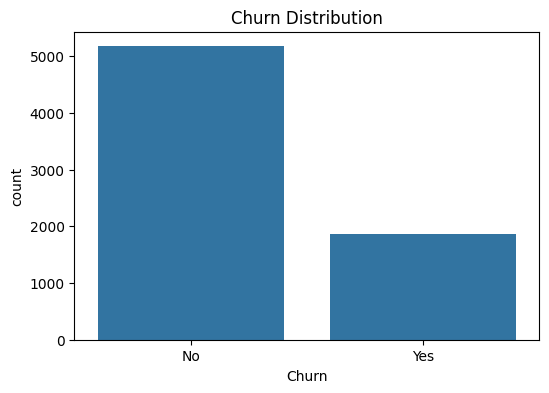

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(
x='Churn',
data=df
)

plt.title("Churn Distribution")
plt.show()

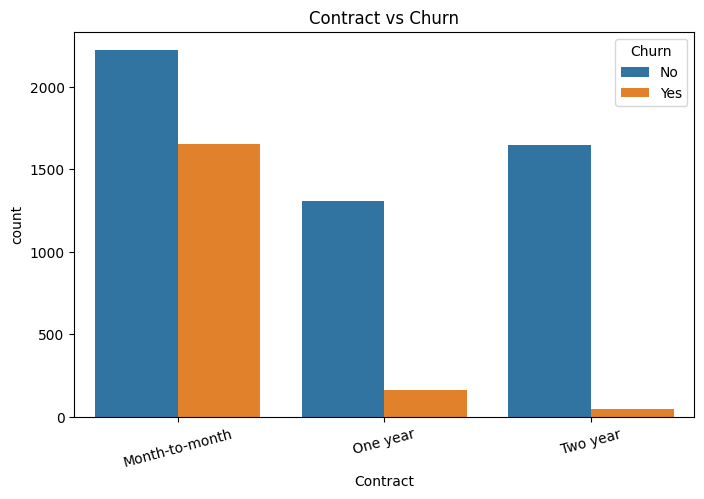

In [15]:
plt.figure(figsize=(8,5))

sns.countplot(
x='Contract',
hue='Churn',
data=df
)

plt.title("Contract vs Churn")
plt.xticks(rotation=15)

plt.show()

In [16]:
df['Churn'] = df['Churn'].replace({
'No': 0,
'Yes': 1
})

print("\n===== CHURN VALUE =====")
print(df['Churn'].value_counts())


===== CHURN VALUE =====
Churn
0    5174
1    1869
Name: count, dtype: int64


In [17]:
categorical_cols = df.select_dtypes(include='object').columns

df = pd.get_dummies(
df,
columns=categorical_cols,
drop_first=True
)

print("\n===== DATA AFTER ENCODING =====")
display(df.head())


===== DATA AFTER ENCODING =====


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [18]:
print("\n===== MISSING VALUE =====")
print(df.isnull().sum().sum())


===== MISSING VALUE =====
0


In [19]:
X = df.drop('Churn', axis=1)

y = df['Churn']

print("\n===== FEATURE SHAPE =====")
print(X.shape)

print("\n===== TARGET SHAPE =====")
print(y.shape)


===== FEATURE SHAPE =====
(7043, 30)

===== TARGET SHAPE =====
(7043,)


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.2,
random_state=42,
stratify=y
)

print("\n===== SPLIT SUCCESS =====")
print(X_train.shape)
print(X_test.shape)


===== SPLIT SUCCESS =====
(5634, 30)
(1409, 30)


In [21]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
X_train,
y_train
)

print("\n===== BEFORE SMOTE =====")
print(y_train.value_counts())

print("\n===== AFTER SMOTE =====")
print(y_train_smote.value_counts())


===== BEFORE SMOTE =====
Churn
0    4139
1    1495
Name: count, dtype: int64

===== AFTER SMOTE =====
Churn
0    4139
1    4139
Name: count, dtype: int64


In [22]:
model = XGBClassifier(
n_estimators=200,
learning_rate=0.05,
max_depth=5,
random_state=42,
eval_metric='logloss'
)

model.fit(
X_train_smote,
y_train_smote
)

print("\n===== MODEL TRAINED =====")


===== MODEL TRAINED =====


In [23]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

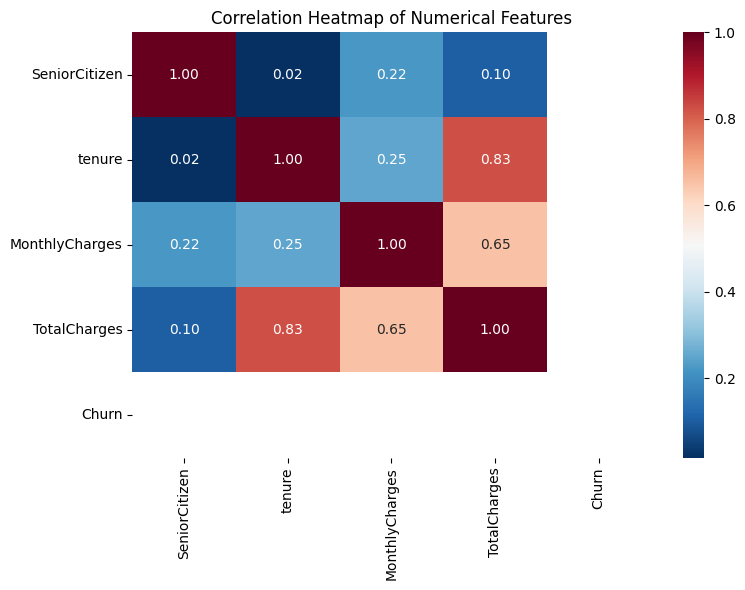

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Copy data
heatmap_df = df.copy()

# Ubah churn menjadi numerik
heatmap_df['Churn'] = heatmap_df['Churn'].map({
    'No': 0,
    'Yes': 1
})

# Pilih fitur numerik utama
cols = [
    'SeniorCitizen',
    'tenure',
    'MonthlyCharges',
    'TotalCharges',
    'Churn'
]

corr = heatmap_df[cols].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='RdBu_r',
    fmt='.2f'
)

plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

In [25]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("\n===== EVALUATION =====")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC AUC : {auc:.4f}")


===== EVALUATION =====
Accuracy : 0.7665
Precision: 0.5527
Recall : 0.6310
F1-Score : 0.5893
ROC AUC : 0.8256


In [26]:
print("\n===== CLASSIFICATION REPORT =====")

print(
classification_report(
y_test,
y_pred
)
)


===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       0.86      0.82      0.84      1035
           1       0.55      0.63      0.59       374

    accuracy                           0.77      1409
   macro avg       0.71      0.72      0.71      1409
weighted avg       0.78      0.77      0.77      1409



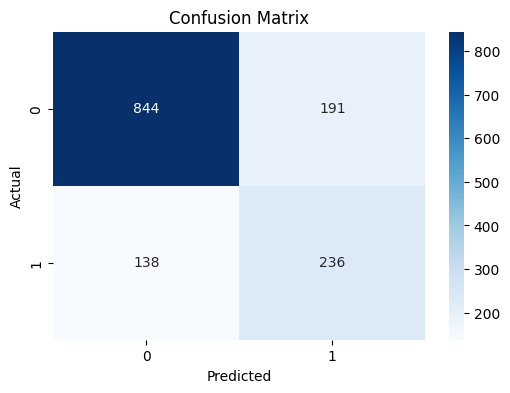

In [27]:
cm = confusion_matrix(
y_test,
y_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
cm,
annot=True,
fmt='d',
cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

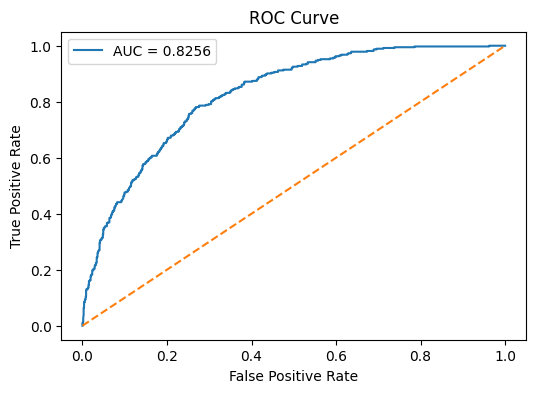

In [28]:
fpr, tpr, thresholds = roc_curve(
y_test,
y_prob
)

plt.figure(figsize=(6,4))

plt.plot(
fpr,
tpr,
label=f"AUC = {auc:.4f}"
)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")
plt.legend()

plt.show()

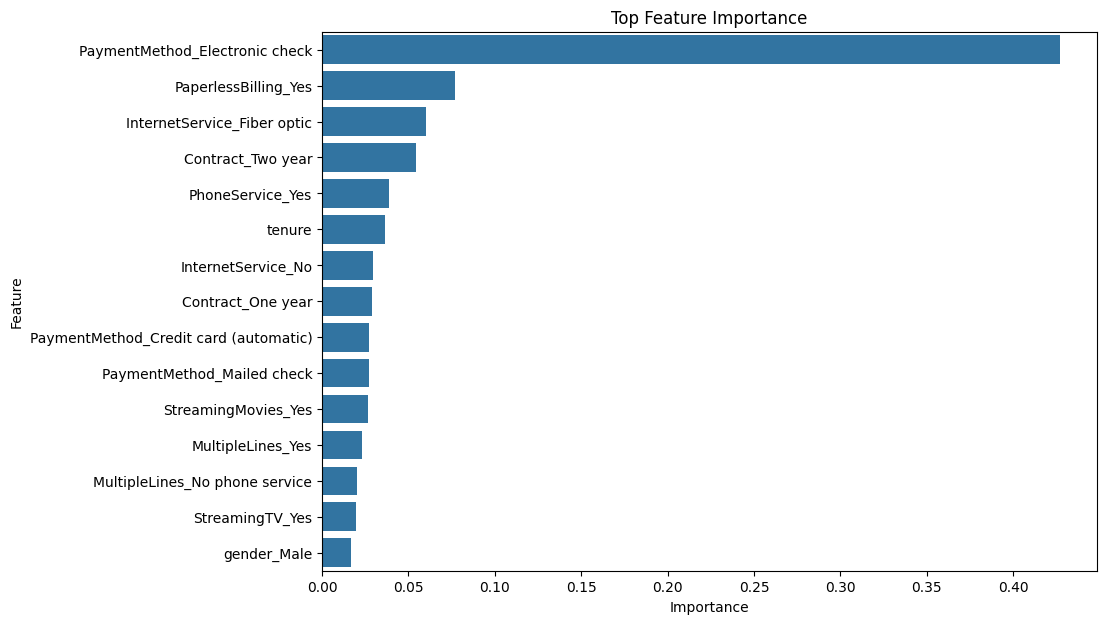

In [29]:
importance = model.feature_importances_

feature_importance = pd.DataFrame({
'Feature': X.columns,
'Importance': importance
})

feature_importance = feature_importance.sort_values(
by='Importance',
ascending=False
)

plt.figure(figsize=(10,7))

sns.barplot(
x='Importance',
y='Feature',
data=feature_importance.head(15)
)

plt.title("Top Feature Importance")

plt.show()


Generating SHAP Summary Plot...


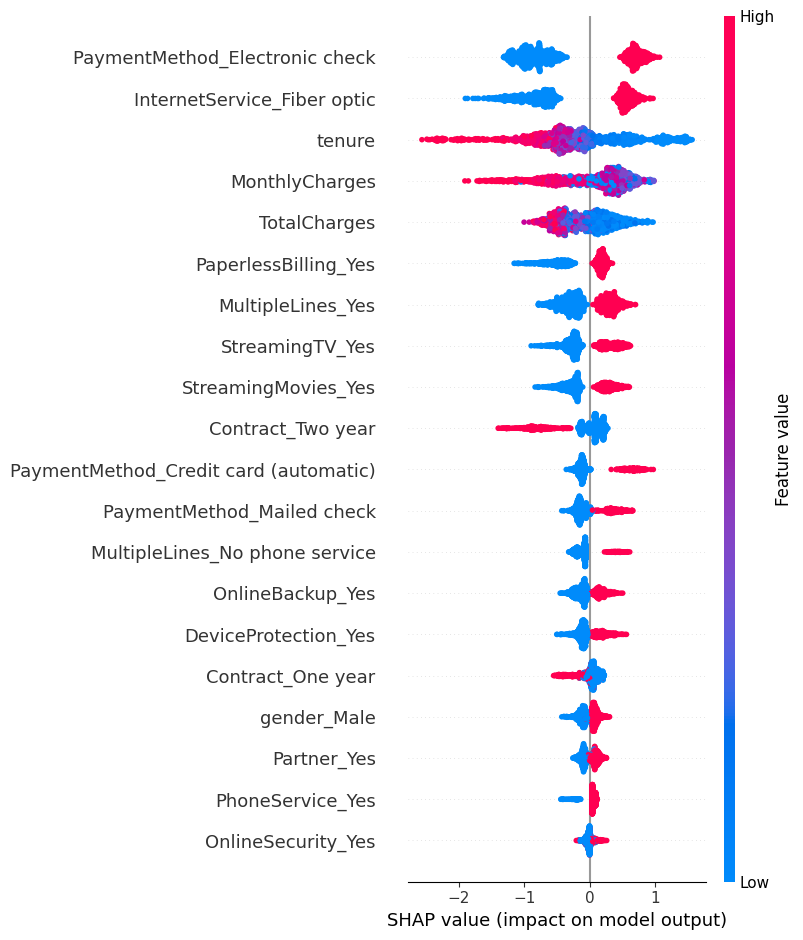

In [30]:
explainer = shap.Explainer(model)

shap_values = explainer(X_test)

print("\nGenerating SHAP Summary Plot...")

shap.summary_plot(
shap_values,
X_test
)

In [31]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

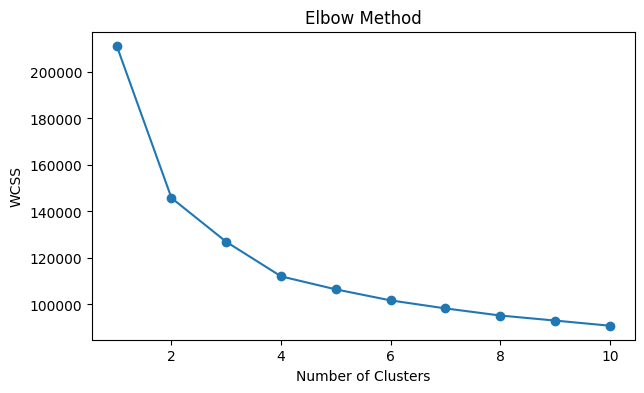

In [32]:
wcss = []

for i in range(1, 11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

# visualisasi elbow
plt.figure(figsize=(7,4))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

In [33]:
kmeans = KMeans(
n_clusters=3,
random_state=42,
n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

print("\n===== CLUSTER RESULT =====")
print(df['Cluster'].value_counts())


===== CLUSTER RESULT =====
Cluster
1    3155
0    2362
2    1526
Name: count, dtype: int64


In [34]:
silhouette = silhouette_score(
X_scaled,
clusters
)

print("\nSilhouette Score:", silhouette)


Silhouette Score: 0.21933537572959633


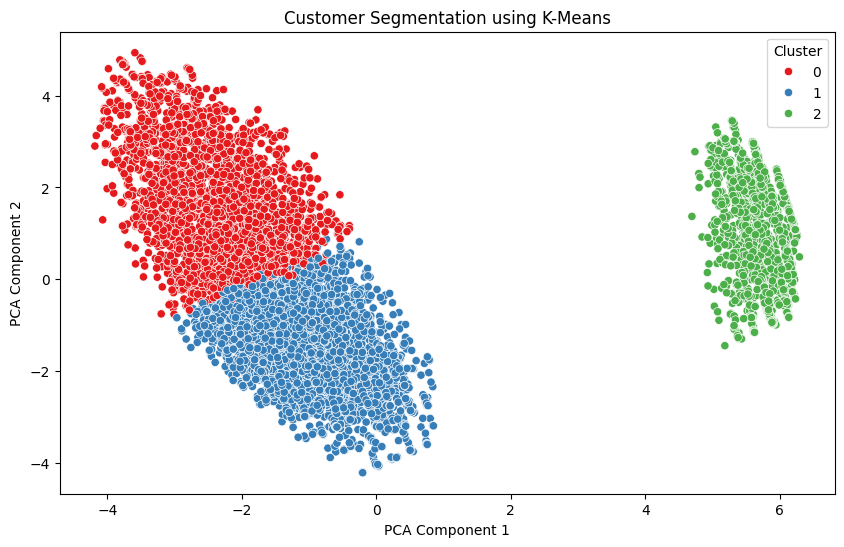

In [39]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# PCA ke 2 dimensi untuk visualisasi
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10,6))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=clusters,
    palette='Set1'
)

plt.title('Customer Segmentation using K-Means')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')

plt.legend(title='Cluster')

plt.show()

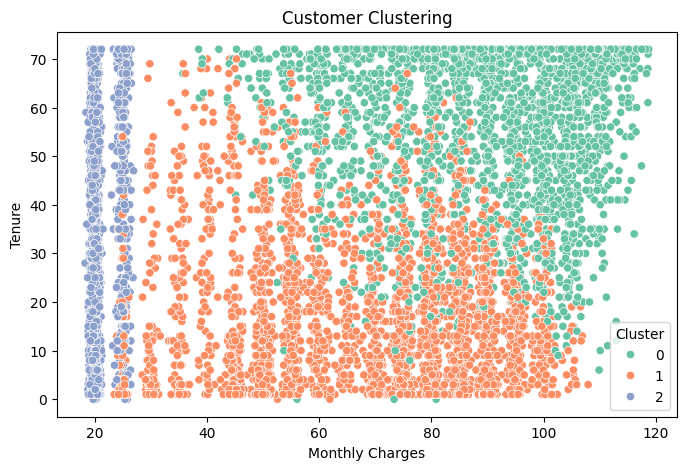

In [35]:
plt.figure(figsize=(8,5))

sns.scatterplot(
x=df['MonthlyCharges'],
y=df['tenure'],
hue=df['Cluster'],
palette='Set2'
)

plt.title("Customer Clustering")

plt.xlabel("Monthly Charges")
plt.ylabel("Tenure")

plt.show()

In [36]:
joblib.dump(
model,
'xgboost_churn_model.pkl'
)

joblib.dump(
scaler,
'scaler.pkl'
)

joblib.dump(
kmeans,
'kmeans_model.pkl'
)

print("\n===== MODEL SAVED =====")


===== MODEL SAVED =====


In [37]:
df.to_csv(
'clean_telco_churn.csv',
index=False
)

print("\n===== CLEAN DATASET SAVED =====")


===== CLEAN DATASET SAVED =====


In [38]:
import joblib

joblib.dump(X.columns.tolist(), "feature_columns.pkl")

['feature_columns.pkl']